In [1]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Set working directory so all relative paths work
os.chdir(r"C:\Users\18594\OneDrive\Desktop\supply-chain-analytics")

# Connect to database
con = duckdb.connect(r"C:\Users\18594\OneDrive\Desktop\supply-chain-analytics\data\processed\supply_chain.duckdb")
master = con.execute("SELECT * FROM master").df()

print(f"✅ Connected to database")
print(f"   Master table: {master.shape[0]:,} rows × {master.shape[1]} columns")
master.head()

✅ Connected to database
   Master table: 96,478 rows × 25 columns


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days_actual,delivery_days_estimated,...,payment_type,review_score,is_low_score,customer_state,customer_city,num_items,total_freight,product_category,seller_id,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,15,...,voucher,4.0,0.0,SP,sao paulo,1,8.72,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,19,...,boleto,4.0,0.0,BA,barreiras,1,22.76,perfumery,289cdb325fb7e7f891c38608bf9e0962,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,26,...,credit_card,5.0,0.0,GO,vianopolis,1,19.22,auto,4869f7a5dfa277a7dca6462dcf3b52b2,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,26,...,credit_card,5.0,0.0,RN,sao goncalo do amarante,1,27.20,pet_shop,66922902710d126a0e7d26b0e3805106,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,12,...,credit_card,5.0,0.0,SP,santo andre,1,8.72,stationery,2c9e548be18521d1c43cde1c582c6de8,SP


In [2]:
print("=== NULL VALUE REPORT ===")
nulls = master.isnull().sum()
nulls_pct = (master.isnull().sum() / len(master) * 100).round(2)
null_report = pd.DataFrame({"null_count": nulls, "null_pct": nulls_pct})
print(null_report[null_report["null_count"] > 0].to_string())

=== NULL VALUE REPORT ===
                               null_count  null_pct
order_approved_at                      14      0.01
order_delivered_carrier_date            2      0.00
order_delivered_customer_date           8      0.01
delivery_days_actual                    8      0.01
total_payment                           1      0.00
num_installments                        1      0.00
payment_type                            1      0.00
review_score                          646      0.67
is_low_score                          646      0.67


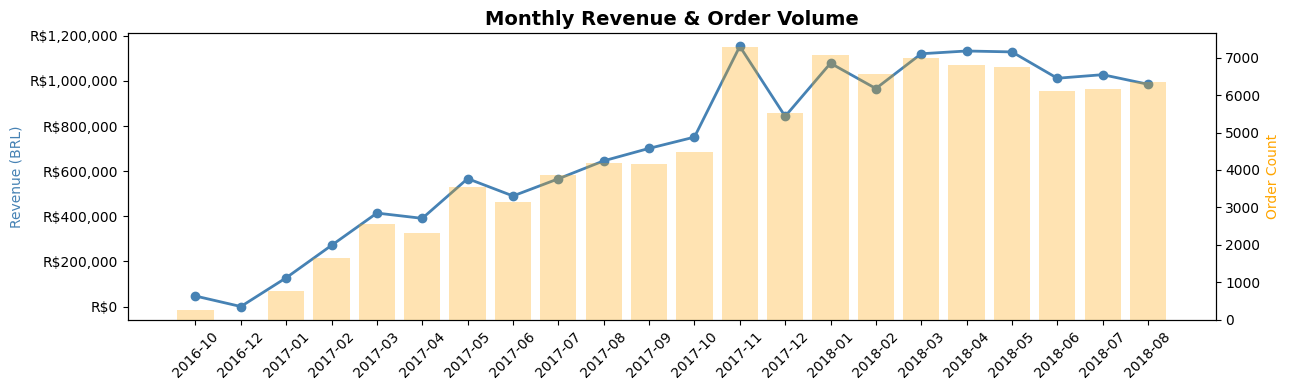

✅ Saved: chart_monthly_revenue.png


In [3]:
monthly = con.execute("""
    SELECT order_month,
           ROUND(SUM(total_payment), 2) AS revenue,
           COUNT(DISTINCT order_id)     AS orders
    FROM master
    WHERE total_payment IS NOT NULL
    GROUP BY order_month
    ORDER BY order_month
""").df()

fig, ax1 = plt.subplots(figsize=(13, 4))

ax1.plot(monthly["order_month"], monthly["revenue"],
         marker="o", color="steelblue", linewidth=2, label="Revenue")
ax1.set_ylabel("Revenue (BRL)", color="steelblue")
ax1.tick_params(axis="x", rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))

ax2 = ax1.twinx()
ax2.bar(monthly["order_month"], monthly["orders"],
        alpha=0.3, color="orange", label="Orders")
ax2.set_ylabel("Order Count", color="orange")

plt.title("Monthly Revenue & Order Volume", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig("data/processed/chart_monthly_revenue.png", dpi=150)
plt.show()
print("✅ Saved: chart_monthly_revenue.png")

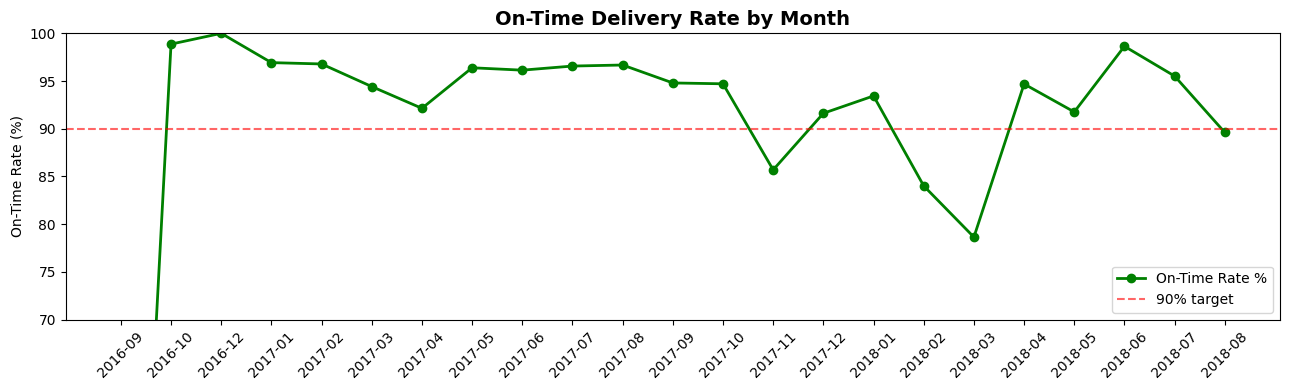

✅ Saved: chart_delivery_rate.png


In [4]:
delivery = con.execute("""
    SELECT order_month,
           ROUND(100.0 * (1 - SUM(is_late) * 1.0 / COUNT(*)), 2) AS on_time_rate,
           ROUND(AVG(delivery_days_actual), 1)                     AS avg_days
    FROM master
    WHERE delivery_days_actual IS NOT NULL
    GROUP BY order_month
    ORDER BY order_month
""").df()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(delivery["order_month"], delivery["on_time_rate"],
        marker="o", color="green", linewidth=2, label="On-Time Rate %")
ax.axhline(y=90, color="red", linestyle="--", alpha=0.6, label="90% target")
ax.set_ylim(70, 100)
ax.set_ylabel("On-Time Rate (%)")
ax.tick_params(axis="x", rotation=45)
ax.set_title("On-Time Delivery Rate by Month", fontsize=14, fontweight="bold")
ax.legend()
fig.tight_layout()
plt.savefig("data/processed/chart_delivery_rate.png", dpi=150)
plt.show()
print("✅ Saved: chart_delivery_rate.png")

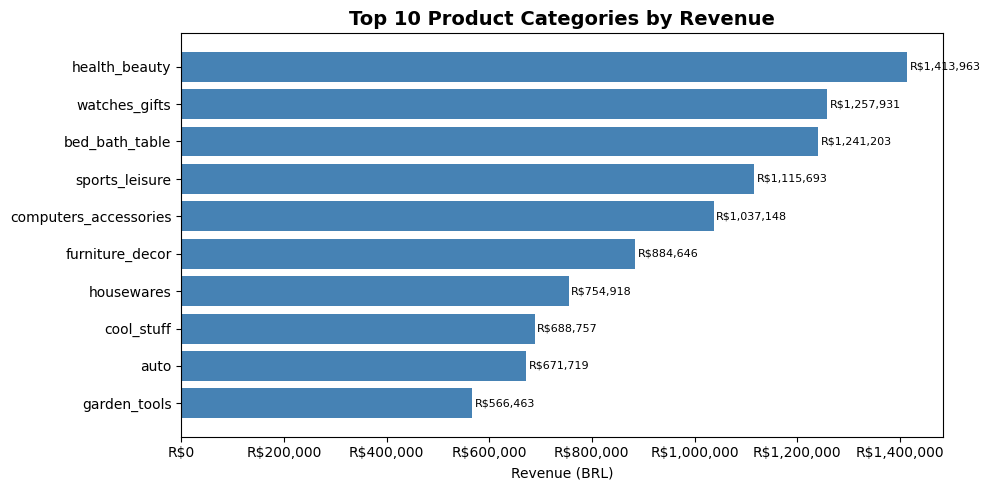

✅ Saved: chart_top_categories.png


In [5]:
cats = con.execute("""
    SELECT product_category,
           ROUND(SUM(total_payment), 2) AS revenue,
           COUNT(DISTINCT order_id)     AS orders,
           ROUND(AVG(review_score), 2)  AS avg_rating
    FROM master
    WHERE product_category IS NOT NULL
    GROUP BY product_category
    ORDER BY revenue DESC
    LIMIT 10
""").df()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cats["product_category"], cats["revenue"], color="steelblue")
ax.set_xlabel("Revenue (BRL)")
ax.set_title("Top 10 Product Categories by Revenue", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
ax.invert_yaxis()

for bar, val in zip(bars, cats["revenue"]):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height() / 2,
            f"R${val:,.0f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("data/processed/chart_top_categories.png", dpi=150)
plt.show()
print("✅ Saved: chart_top_categories.png")

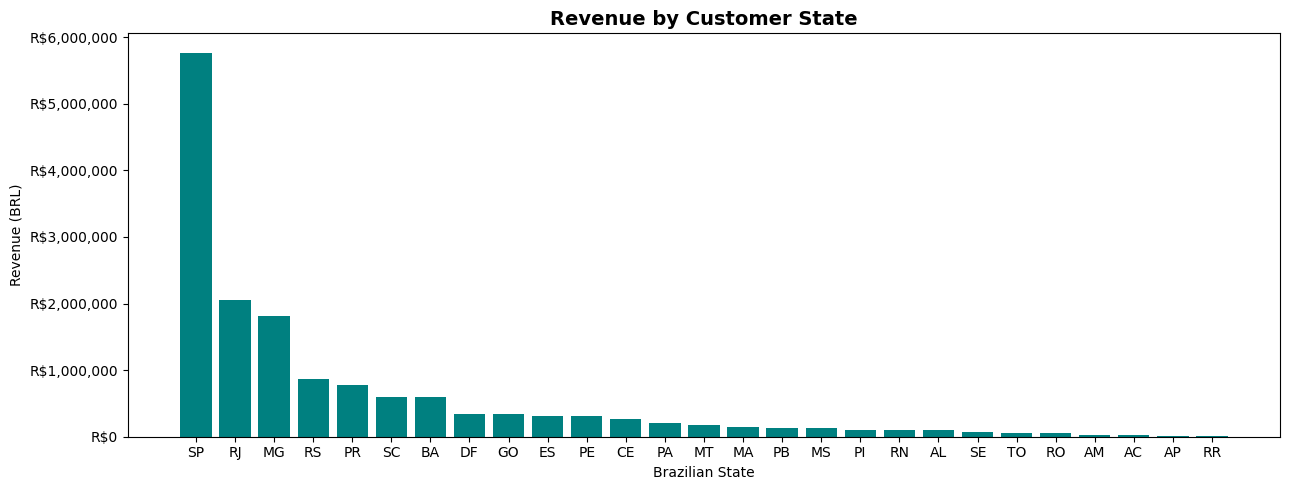

✅ Saved: chart_geography.png


In [6]:
geo = con.execute("""
    SELECT customer_state,
           ROUND(SUM(total_payment), 2) AS revenue,
           COUNT(DISTINCT order_id)     AS orders
    FROM master
    GROUP BY customer_state
    ORDER BY revenue DESC
""").df()

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(geo["customer_state"], geo["revenue"], color="teal")
ax.set_xlabel("Brazilian State")
ax.set_ylabel("Revenue (BRL)")
ax.set_title("Revenue by Customer State", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
plt.tight_layout()
plt.savefig("data/processed/chart_geography.png", dpi=150)
plt.show()
print("✅ Saved: chart_geography.png")

In [7]:
print("=" * 55)
print("📊 SUPPLY CHAIN ANALYTICS — KEY FINDINGS")
print("=" * 55)

findings = {
    "Total Revenue":          "R$15,422,461",
    "Total Orders":           "96,478",
    "Avg Order Value":        "R$159.86",
    "Avg Delivery Days":      "12.1 days",
    "On-Time Delivery Rate":  "91.89%",
    "Late Delivery Rate":     "8.11%",
    "Avg Review Score":       "4.16 / 5.0",
    "States Served":          "27",
    "Active Sellers":         "2,960",
}

for k, v in findings.items():
    print(f"  {k:<26} {v}")

print("=" * 55)
print("\n📌 Notable Findings:")
print("  • Peak revenue month: Nov 2017 (Black Friday effect)")
print("  • SP state dominates: ~40% of all revenue")
print("  • health_beauty is top revenue category")
print("  • Late deliveries spike in early 2018")
print("  • Credit card used in ~74% of all orders")

📊 SUPPLY CHAIN ANALYTICS — KEY FINDINGS
  Total Revenue              R$15,422,461
  Total Orders               96,478
  Avg Order Value            R$159.86
  Avg Delivery Days          12.1 days
  On-Time Delivery Rate      91.89%
  Late Delivery Rate         8.11%
  Avg Review Score           4.16 / 5.0
  States Served              27
  Active Sellers             2,960

📌 Notable Findings:
  • Peak revenue month: Nov 2017 (Black Friday effect)
  • SP state dominates: ~40% of all revenue
  • health_beauty is top revenue category
  • Late deliveries spike in early 2018
  • Credit card used in ~74% of all orders
